In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("c:\\Users\\omkar\\Downloads\\sms_spam_collection (1).csv")

In [3]:
df.sample(10) #randomly sample 10 rows from the dataframe

,label,message
2432,ham,That's good. Lets thank God. Please complete t...
2941,spam,You have 1 new message. Please call 08712400200.
1329,ham,My exam is for february 4. Wish you a great day.
1871,ham,"Aight, I'll text you when I'm back"
508,ham,You should know now. So how's anthony. Are you...
1297,ham,Sure! I am driving but will reach my destinati...
2354,spam,Please CALL 08712402902 immediately as there i...
177,ham,U still going to the mall?
3267,ham,tap & spile at seven. * Is that pub on gas st ...
1289,ham,Happy new year to u too!


In [4]:
#Workflow Of Project
#1. Data Cleaning
#2. Exploratory Data Analysis(EDA)
#3. Text Preprocessing
#4. Model Building
#5. Evaluation  
#6. Improvement
#7. Website Building

In [5]:
#DATA CLEANING

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
# Have very good amount of non-null values. No need to handle missing values.

In [8]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [9]:
df['label'] = encoder.fit_transform(df['label']) #assigning 0 and 1 to ham and spam respectively

In [10]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
#Checking Missing Values
df.isnull().sum()

label      0
message    0
dtype: int64

In [12]:
#Checking Duplicate Values
df.duplicated().sum()

np.int64(403)

In [13]:
#Removing Duplicate Values
df = df.drop_duplicates(keep='first')

In [14]:
#Checking Duplicate Values Again
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(5169, 2)

In [16]:
#data cleaning is done. We have 5169 rows and 2 columns in our dataset.

In [17]:
#EXPLORATORY DATA ANALYSIS(EDA)

In [18]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
df['label'].value_counts() 
#checking the distribution of ham and spam messages

label
0    4516
1     653
Name: count, dtype: int64

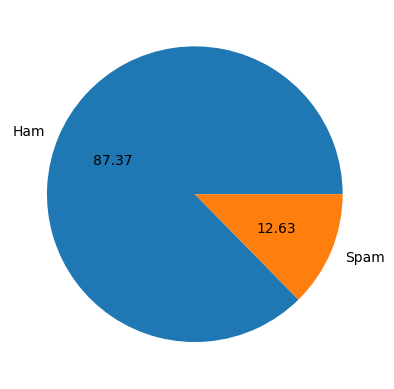

In [20]:
import matplotlib.pyplot as plt
plt.pie(df['label'].value_counts(), labels=['Ham', 'Spam'], autopct='%1.2f')
plt.show()

In [21]:
#We can see that the dataset is imbalanced as the number of ham 
# messages are more than spam messages.

In [22]:
#Now, we will create 3 new columns in our dataset which will give us more insights about the messages.
#These columns are:
#1. Number of characters in the message
#2. Number of words in the message
#3. Number of sentences in the message

In [23]:
import nltk

In [24]:
nltk.download('punkt') #downloading the punkt package for tokenization
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to C:\Users\omkar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\omkar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [25]:
#number of characters in the message
df['char_count'] = df['message'].apply(len)

In [26]:
df.head()

,label,message,char_count
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [27]:
#number of words in the message
df['word_count'] = df['message'].apply(lambda x: len(nltk.word_tokenize(x)))

In [28]:
df.head()

,label,message,char_count,word_count
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [29]:
#number of sentences in the message
df['sentence_count'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))    

In [30]:
df.head()

,label,message,char_count,word_count,sentence_count
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [31]:
#Analyzing overall insights 
df[['char_count', 'word_count', 'sentence_count']].describe()

,char_count,word_count,sentence_count
count,5169.000000,5169.000000,5169.000000
mean,79.344554,18.593925,1.974076
std,58.437457,13.403137,1.458967
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,119.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [32]:
#seperating ham and spam messages into different dataframes for better analysis
#ham
df[df['label'] == 0][['char_count', 'word_count', 'sentence_count']].describe() #ham messages


,char_count,word_count,sentence_count
count,4516.000000,4516.000000,4516.000000
mean,70.905890,17.268158,1.827724
std,56.715046,13.588513,1.394338
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,91.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [33]:
#spam
df[df['label'] == 1][['char_count', 'word_count', 'sentence_count']].describe() #ham messages

,char_count,word_count,sentence_count
count,653.000000,653.000000,653.000000
mean,137.704441,27.762634,2.986217
std,29.821348,6.993008,1.494815
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,9.000000


In [34]:
import seaborn as sns

<Axes: xlabel='char_count', ylabel='Count'>

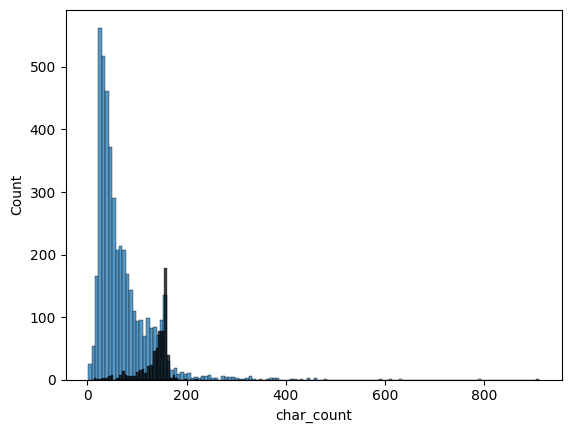

In [35]:
sns.histplot(df[df['label'] == 0]['char_count']) #ham messages
sns.histplot(df[df['label'] == 1]['char_count'],color='black')  #spam messages

<Axes: xlabel='word_count', ylabel='Count'>

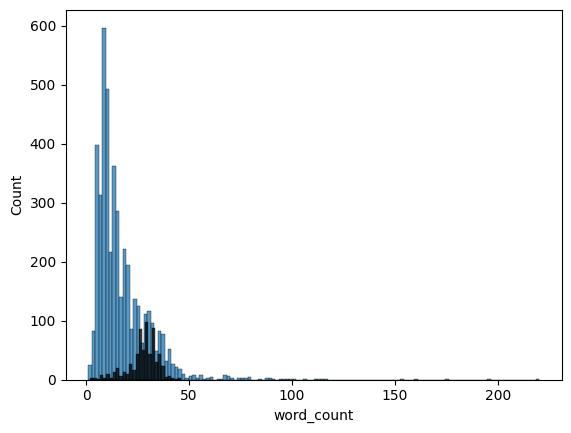

In [36]:
sns.histplot(df[df['label'] == 0]['word_count']) #ham messages
sns.histplot(df[df['label'] == 1]['word_count'],color='black')  #spam messages

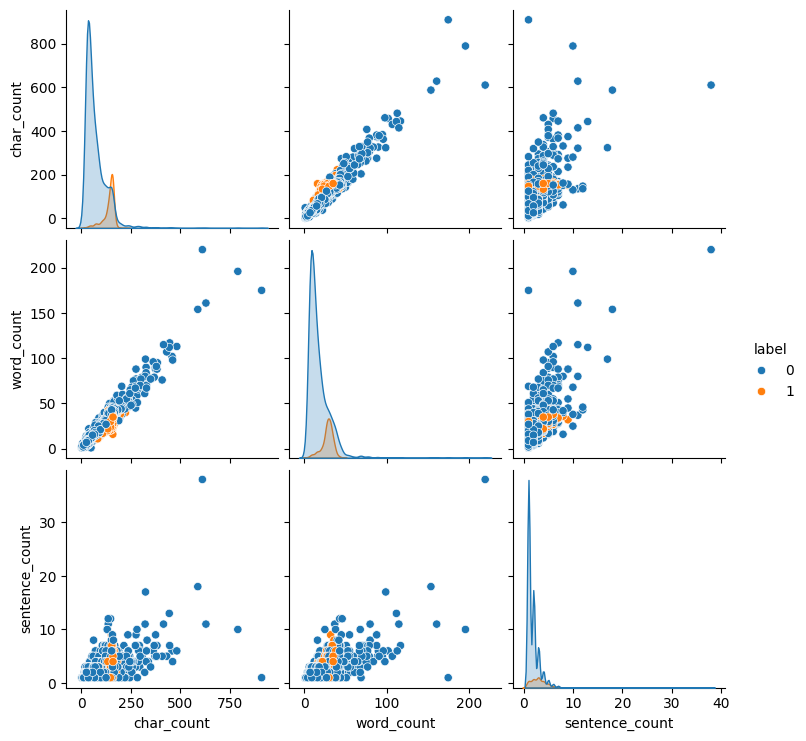

In [37]:
#Now analysing what kind of relationship exists between the label and the message variable. 
#We will use apairplot to visualize the correlation between the labels and the messages variable.
sns.pairplot(df, hue='label')

<Axes: >

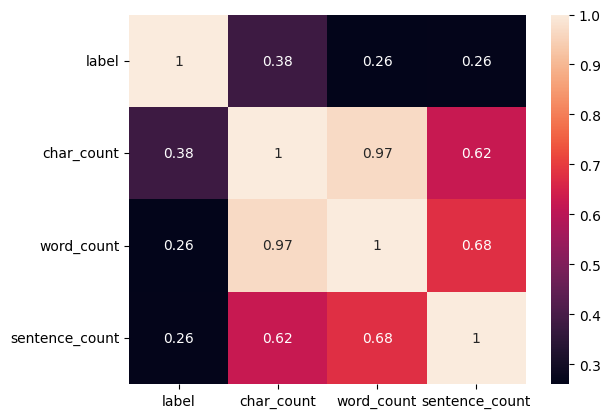

In [38]:
sns.heatmap(df[['label', 'char_count', 'word_count', 'sentence_count']].corr(), annot=True)

In [39]:
#DATA PREPROCESSING

In [40]:
import string
string.punctuation
s = string.punctuation

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# For Stemming

from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\omkar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [41]:
#Creating a new function for text preprocessing which will perform the following tasks:
#1. Converting all the characters to lowercase
#2. Removing special characters and numbers
#3. Removing stop words and punctuations
#4. Stemming

def transform_message(message):
    message = message.lower() #converting all the characters to lowercase
    message = nltk.word_tokenize(message) #tokenization

    y = []
    for i in message:
        if i.isalnum():
            y.append(i) #removing Special Characters and Numbers

    message = y[:] #reassigning the message variable to the list y which contains only alphanumeric characters
    y.clear() #clearing the list to reuse it for removing stop words and punctuations

    for i in message:
        if i not in stop_words and i not in s:
            y.append(i) #removing Stop Words and Punctuations        
    
    message = y[:]
    y.clear()

    for i in message:
        y.append(ps.stem(i)) #performing stemming

    return " ".join(y) #joining the list y to form a string and returning it

In [42]:
transform_message('Hello World! This is a sample message.')

'hello world sampl messag'

In [43]:
df['transformed_message']  = df['message'].apply(transform_message)

In [44]:
df.head()

,label,message,char_count,word_count,sentence_count,transformed_message
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [45]:
#MODEL BUILDING
#We will use Naive Bayes algorithm
#We will use CountVectorizer to convert the text data into numerical data
#which can be used by the machine learning algorithm.


from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
cv = CountVectorizer()
tfidf = TfidfTransformer()


In [46]:
X =  tfidf.fit_transform(cv.fit_transform(df['transformed_message'])).toarray()

In [47]:
X #Sparse Matrix of the transformed messages

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 6782))

In [48]:
X.shape

(5169, 6782)

In [49]:
y =  df['label'].values

In [50]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [51]:
#Train-Test Split
from sklearn.model_selection import train_test_split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [53]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
model = MultinomialNB()

In [54]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))

0.9593810444874274
[[908   0]
 [ 42  84]]
1.0
0.6666666666666666


In [55]:
#Precision is the most important metric for our model as we want to minimize
#the number of false positives (ham messages classified as spam).
#As precision = 1 in TfIdf vectorizer but not in count vectorizer so
#we will use TfIdf vectorizer for our model.

In [56]:
import pickle

pickle.dump(cv, open('count_vectorizer.pkl', 'wb'))
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(model, open('model.pkl', 'wb'))

In [57]:
import os

print(os.path.exists("count_vectorizer.pkl"))

True


In [58]:
import pickle

cv = pickle.load(open("count_vectorizer.pkl", "rb"))
tfidf = pickle.load(open("vectorizer.pkl", "rb"))
model = pickle.load(open("model.pkl", "rb"))

print(type(cv))
print(type(tfidf))
print(type(model))

<class 'sklearn.feature_extraction.text.CountVectorizer'>
<class 'sklearn.feature_extraction.text.TfidfTransformer'>
<class 'sklearn.naive_bayes.MultinomialNB'>
